In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('archive/adult.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
import numpy as np

df[df == '?'] = np.nan
y_label_map = {'<=50K': 0, '>50K': 1}
df['income>50K'] = df['income'].map(y_label_map)
# for col in ['workclass', 'occupation', 'native.country']:
#     print(col, ' nan -> ', df[col].mode()[0])
#     df.fillna({col: df[col].mode()[0]}, inplace=True)

In [7]:
df[['income', 'income>50K']].sample(10)

,income,income>50K
13115,<=50K,0
9410,<=50K,0
17660,>50K,1
21464,<=50K,0
4749,>50K,1
4858,>50K,1
18515,>50K,1
14745,<=50K,0
9238,<=50K,0
29529,<=50K,0


In [8]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
income>50K           0
dtype: int64

In [9]:
min(df.age), max(df.age)

(17, 90)

In [10]:
min(df['education.num']), max(df['education.num'])

(1, 16)

In [11]:
min(df['hours.per.week']), max(df['hours.per.week'])

(1, 99)

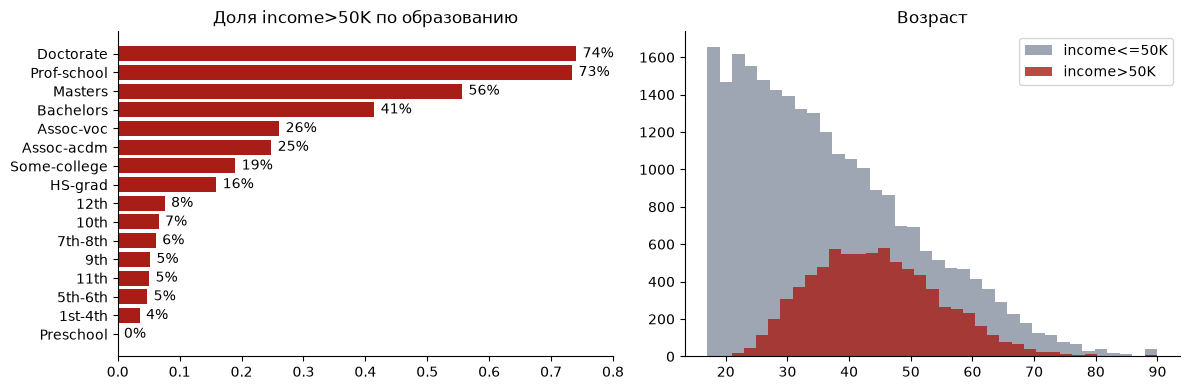

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

by_contract = df.groupby("education")["income>50K"].mean().sort_values()
axes[0].barh(by_contract.index, by_contract.values, color="#A81E17")
axes[0].set_title("Доля income>50K по образованию")
axes[0].set_xlim(0, 0.8)
for i, v in enumerate(by_contract.values):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va="center")

axes[1].hist(df.loc[df["income>50K"] == 0, "age"], bins=36, alpha=0.6, label="income<=50K", color="#5C6B80")
axes[1].hist(df.loc[df["income>50K"] == 1, "age"], bins=36, alpha=0.8, label="income>50K", color="#A81E17")
axes[1].set_title("Возраст")
axes[1].legend()
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [13]:
TARGET = "income>50K"
DROP = ["fnlwgt", "income", TARGET]
X = df.drop(columns=DROP)
y = df[TARGET]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
print(X_train.shape, X_test.shape)
print(f"доля income>50K: train {y_train.mean():.3f}, test {y_test.mean():.3f}")

(26048, 13) (6513, 13)
доля income>50K: train 0.241, test 0.241


In [15]:
numeric_cols = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("числовые:", numeric_cols)
print("категориальные:", categorical_cols)

числовые: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
категориальные: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])
logreg.fit(X_train, y_train)

def report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    row = {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred),
        f"recall@{threshold}": recall_score(y_true, pred),
        f"F1@{threshold}": f1_score(y_true, pred),
    }
    return row

proba_lr = logreg.predict_proba(X_test)[:, 1]
results = [report("logreg", y_test, proba_lr)]
pd.DataFrame(results).round(3)

,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.905,0.763,0.74,0.587,0.655


порог 0.387: recall 0.700, precision 0.670


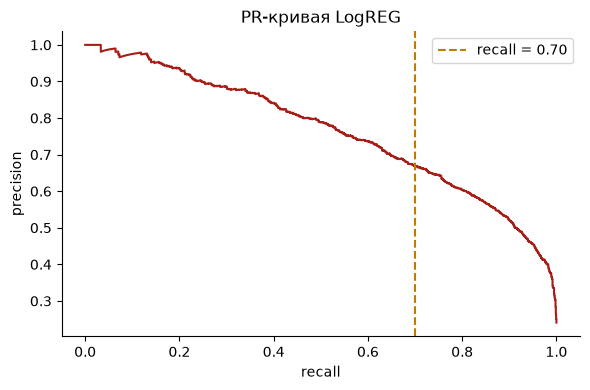

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_lr)
mask = recall[:-1] >= 0.70
best_threshold_lr = thresholds[mask].max()
pred = (proba_lr >= best_threshold_lr).astype(int)
print(f"порог {best_threshold_lr:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#A81E17")
plt.axvline(0.70, color="#C07C00", linestyle="--", label="recall = 0.70")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("PR-кривая LogREG")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [18]:
from catboost import CatBoostClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=0
)
X_tr_cb, X_val_cb, X_test_cb = X_tr.copy(), X_val.copy(), X_test.copy()
for frame in (X_tr_cb, X_val_cb, X_test_cb):
    frame["workclass"] = frame["workclass"].fillna("")
    frame["occupation"] = frame["occupation"].fillna("")
    frame["native.country"] = frame["native.country"].fillna("")

cat = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="AUC", random_seed=0, verbose=0,
)
cat.fit(X_tr_cb, y_tr, cat_features=categorical_cols,
        eval_set=(X_val_cb, y_val), early_stopping_rounds=50)

print("лучшая итерация:", cat.get_best_iteration())
proba_cb = cat.predict_proba(X_test_cb)[:, 1]
results.append(report("catboost", y_test, proba_cb))
pd.DataFrame(results).round(3)

лучшая итерация: 751


,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.905,0.763,0.740,0.587,0.655
1,catboost,0.929,0.828,0.767,0.666,0.713


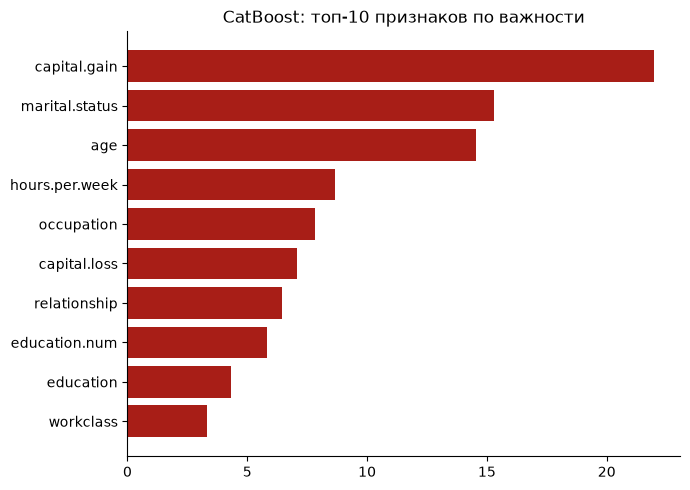

In [19]:
importances = pd.Series(cat.get_feature_importance(), index=X_tr_cb.columns).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(importances.index[-10:], importances.values[-10:], color="#A81E17")
plt.title("CatBoost: топ-10 признаков по важности")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

порог 0.473: recall 0.700, precision 0.755


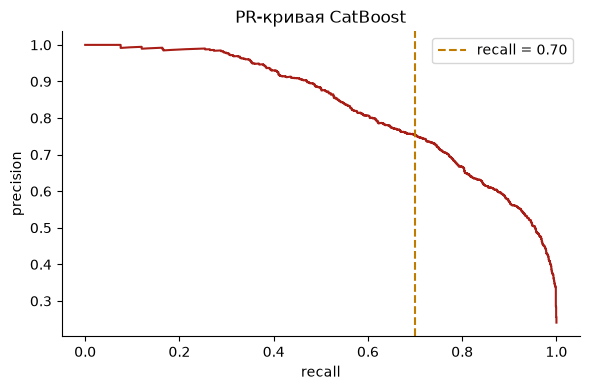

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_cb)
mask = recall[:-1] >= 0.70
best_threshold = thresholds[mask].max()
pred = (proba_cb >= best_threshold).astype(int)
print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#A81E17")
plt.axvline(0.70, color="#C07C00", linestyle="--", label="recall = 0.70")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("PR-кривая CatBoost")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [21]:
import sklearn, catboost
from pathlib import Path
import joblib
import json

ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)

metadata = {
    "model_name": "income>50K-baseline",
    "model_version": "0.1.0",
    "trained_at": pd.Timestamp.now('UTC').isoformat(timespec="seconds"),
    "n_train": int(len(X_train)),
    "features": list(X.columns),
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "threshold_lr": float(round(best_threshold_lr, 4)), # best_threshold for LogReg
    "threshold_cb": float(round(best_threshold, 4)), # best_threshold for CatBoost
    "metrics_test_lr": {k: round(float(v), 4) for k, v in results[0].items() if k != "model"}, # metrics for LogReg
    "metrics_test_cb": {k: round(float(v), 4) for k, v in results[1].items() if k != "model"}, # metrics for CatBoost
    "libs": {"pandas": pd.__version__, "scikit-learn": sklearn.__version__, "catboost": catboost.__version__},
}

joblib.dump({"pipeline": logreg, "metadata": {**metadata, "model_name": "income>50K-logreg"}},
            ARTIFACTS / "baseline_logreg.joblib")
cat.save_model(str(ARTIFACTS / "baseline_catboost.cbm"))
(ARTIFACTS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

sorted(p.name for p in ARTIFACTS.iterdir())

['baseline_catboost.cbm', 'baseline_logreg.joblib', 'metadata.json']

In [22]:
metadata["metrics_test_cb"]

{'ROC-AUC': 0.929,
 'PR-AUC': 0.8277,
 'precision@0.5': 0.7673,
 'recall@0.5': 0.6665,
 'F1@0.5': 0.7133}

In [23]:
bundle = joblib.load(ARTIFACTS / "baseline_logreg.joblib")
pipe, meta = bundle["pipeline"], bundle["metadata"]
payload = X_test.iloc[0].to_dict()          # так придёт запрос: dict
frame = pd.DataFrame([payload])[meta["features"]]   # порядок колонок как при обучении

score = float(pipe.predict_proba(frame)[0, 1])
print(json.dumps({"score": round(score, 4),
                  "income>50K": bool(score >= meta["threshold_lr"]),
                  "model_version": meta["model_version"]}, ensure_ascii=False))

{"score": 0.0024, "income>50K": false, "model_version": "0.1.0"}


In [24]:
batch_score = pipe.predict_proba(X_test)[0, 1]
assert abs(batch_score - score) < 1e-9, "train-serve skew: одна строка и батч дают разные ответы"
print("одна строка и батч совпадают до 1e-9")

одна строка и батч совпадают до 1e-9


In [25]:
X_test[y_test == 1].iloc[2].to_dict()

{'age': 47,
 'workclass': 'Private',
 'education': 'Bachelors',
 'education.num': 13,
 'marital.status': 'Married-civ-spouse',
 'occupation': 'Exec-managerial',
 'relationship': 'Husband',
 'race': 'White',
 'sex': 'Male',
 'capital.gain': 0,
 'capital.loss': 0,
 'hours.per.week': 45,
 'native.country': 'United-States'}

In [26]:
X_test[y_test == 0].iloc[0].to_dict()

{'age': 39,
 'workclass': 'Private',
 'education': 'HS-grad',
 'education.num': 9,
 'marital.status': 'Divorced',
 'occupation': 'Priv-house-serv',
 'relationship': 'Unmarried',
 'race': 'White',
 'sex': 'Female',
 'capital.gain': 0,
 'capital.loss': 0,
 'hours.per.week': 22,
 'native.country': 'United-States'}